In [1]:
from tabulate import tabulate
from math import inf

headers = ["Benchmark Name", "OnePerc Depth", "OnePerc+skew Depth", "OneMem Depth", 'Depth Improv. vs OnePerc', 'Depth Improv. vs OnePerc+skew', 'OnePerc Life Time', 'OnePerc+skew Life Time', 'OneMem Life Time', 'Life Time Improv. vs OnePerc', 'Life Time Improv. vs OnePerc+skew', 'OnePerc Measure Delay', 'OnePerc+skew Measure Delay', 'OneMem Measure Delay']

N_list = [6, 8, 10]
algorithm_type = ["QAOA", "RCA", "VQE"]
RefreshBound_list = [20]

data = []

with open("data/main_table.txt", "r") as file:
    oneperc_actual_life_time_list = eval(file.readline())
    oneperc_br_actual_life_time_list = eval(file.readline())
    onemem_actual_life_time_list = eval(file.readline())
    oneperc_refresh_layer_index_list = eval(file.readline())
    oneperc_br_refresh_layer_index_list = eval(file.readline())
    onemem_refresh_layer_index_list = eval(file.readline())
    max_oneperc_measure_delay_list = eval(file.readline())
    max_oneperc_br_measure_delay_list = eval(file.readline())
    max_onemem_measure_delay_list = eval(file.readline())

for i, N in enumerate(N_list):
    improv_depth_index = 0
    improv_life_time_index = 0
    wait_time_index = 0
    index = 0
    excess = 0

    for a in algorithm_type:
        data.append([])
        data[-1].append(a + '-' + str(N ** 2))
        data[-1].append(oneperc_refresh_layer_index_list[a][i])
        data[-1].append(oneperc_br_refresh_layer_index_list[a][i])
        data[-1].append(onemem_refresh_layer_index_list[a][i])
        data[-1].append(oneperc_refresh_layer_index_list[a][i] / onemem_refresh_layer_index_list[a][i])
        data[-1].append(oneperc_br_refresh_layer_index_list[a][i] / onemem_refresh_layer_index_list[a][i])
        data[-1].append(oneperc_actual_life_time_list[a][i])
        data[-1].append(oneperc_br_actual_life_time_list[a][i])
        data[-1].append(onemem_actual_life_time_list[a][i])         
        data[-1].append(oneperc_actual_life_time_list[a][i] / onemem_actual_life_time_list[a][i])
        data[-1].append(oneperc_br_actual_life_time_list[a][i] / onemem_actual_life_time_list[a][i])
        data[-1].append(max_oneperc_measure_delay_list[a][i])
        data[-1].append(max_oneperc_br_measure_delay_list[a][i])
        data[-1].append(max_onemem_measure_delay_list[a][i])

with open("data/main_table_uccsd.txt", 'r') as file:
    oneperc_actual_life_time_list = eval(file.readline())
    oneperc_br_actual_life_time_list = eval(file.readline())
    onemem_actual_life_time_list = eval(file.readline())
    oneperc_refresh_layer_index_list = eval(file.readline())
    oneperc_br_refresh_layer_index_list = eval(file.readline())
    onemem_refresh_layer_index_list = eval(file.readline())
    max_oneperc_measure_delay_list = eval(file.readline())
    max_oneperc_br_measure_delay_list = eval(file.readline())
    max_onemem_measure_delay_list = eval(file.readline())  

a = 'UCCSD'
name_list = [r'$H_2O$', r'$CH_4$', r'$C_2H_6$']
for i in range(3): 
    data.append([])
    data[-1].append(name_list[i])
    data[-1].append(oneperc_refresh_layer_index_list[a][i])
    data[-1].append(oneperc_br_refresh_layer_index_list[a][i])
    data[-1].append(onemem_refresh_layer_index_list[a][i])
    data[-1].append(oneperc_refresh_layer_index_list[a][i] / onemem_refresh_layer_index_list[a][i])
    data[-1].append(oneperc_br_refresh_layer_index_list[a][i] / onemem_refresh_layer_index_list[a][i])
    data[-1].append(oneperc_actual_life_time_list[a][i])
    data[-1].append(oneperc_br_actual_life_time_list[a][i])
    data[-1].append(onemem_actual_life_time_list[a][i])         
    data[-1].append(oneperc_actual_life_time_list[a][i] / onemem_actual_life_time_list[a][i])
    data[-1].append(oneperc_br_actual_life_time_list[a][i] / onemem_actual_life_time_list[a][i])
    
    data[-1].append(max_oneperc_measure_delay_list[a][i])
    data[-1].append(max_oneperc_br_measure_delay_list[a][i])
    data[-1].append(max_onemem_measure_delay_list[a][i])  

table = tabulate(data, headers, tablefmt="grid")
print(table)

improv_idx = 0
for d in data:
    improv_idx += d[5]
    print(d[0],
            "&", format(d[1], ','),
            "&", format(d[2], ','), 
            "&", format(d[3], ','), 
            "& \\textbf{", round(d[4], 2),"$\\times$}", 
            "&", round(d[5], 2),"$\\times$",
            "&", format(d[6], ','), 
            "&", format(d[7], ','), 
            "&", format(d[8], ','),
            "&", format(d[11], ','), 
            "&", format(d[12], ','), 
            "& \\textbf{", format(d[13], ','), "}\\\\")
    print("\hline")
print(improv_idx / len(data))

+------------------+-----------------+----------------------+----------------+----------------------------+---------------------------------+---------------------+--------------------------+--------------------+--------------------------------+-------------------------------------+-------------------------+------------------------------+------------------------+
| Benchmark Name   |   OnePerc Depth |   OnePerc+skew Depth |   OneMem Depth |   Depth Improv. vs OnePerc |   Depth Improv. vs OnePerc+skew |   OnePerc Life Time |   OnePerc+skew Life Time |   OneMem Life Time |   Life Time Improv. vs OnePerc |   Life Time Improv. vs OnePerc+skew |   OnePerc Measure Delay |   OnePerc+skew Measure Delay |   OneMem Measure Delay |
+==================+=================+======================+================+============================+=================================+=====================+==========================+====================+================================+==========================

In [2]:
# memoriless table
from tabulate import tabulate

headers = ["Benchmark Name", "Qiskit Depth", "Qiskit Braiding Depth", 'Braiding Qiskit vs Qiskit', 'Memoriless OneMem Depth', 'OneMem vs Qiskit']

N_list = [6, 8, 10]
algorithm_type = ["QAOA", "RCA", "VQE"]
Round = 1


with open("data/memoriless.txt", "r") as file:
    qiskit_depth_list = eval(file.readline())
    qiskit_braiding_depth_list = eval(file.readline())
    onemem_layer_index_list = eval(file.readline())

improv_idx = 0
data = []
for n in range(len(N_list)): 
    for a in algorithm_type:
        improv_idx += qiskit_depth_list[a][n] / onemem_layer_index_list[a][n]
        data.append([])
        data[-1].append(a + '-' + str(N_list[n] ** 2))
        data[-1].append(qiskit_depth_list[a][n])
        data[-1].append(qiskit_braiding_depth_list[a][n])
        data[-1].append(onemem_layer_index_list[a][n])
        data[-1].append(qiskit_depth_list[a][n] / onemem_layer_index_list[a][n]) 
        data[-1].append(qiskit_braiding_depth_list[a][n] / onemem_layer_index_list[a][n]) 

with open("data/memoriless_uccsd.txt", "r") as file:
    qiskit_depth_list = eval(file.readline())
    qiskit_braiding_depth_list = eval(file.readline())
    onemem_layer_index_list = eval(file.readline())

name_list = [r'$H_2O$', r'$CH_4$', r'$C_2H_6$']
a = 'UCCSD'

for i in range(3):
    improv_idx += qiskit_depth_list[a][i] / onemem_layer_index_list[a][i]
    data.append([])
    data[-1].append(name_list[i])
    data[-1].append(qiskit_depth_list[a][i])
    data[-1].append(qiskit_braiding_depth_list[a][i])
    data[-1].append(onemem_layer_index_list[a][i])
    data[-1].append(qiskit_depth_list[a][i] / onemem_layer_index_list[a][i]) 
    data[-1].append(qiskit_braiding_depth_list[a][i] / onemem_layer_index_list[a][i]) 
print(improv_idx / len(data))
table = tabulate(data, headers, tablefmt="grid")
print(table)

for d in data:
    print(d[0],"&", 
          format(d[1], ','), "&", 
          format(d[2], ','), "&", 
          format(d[3], ','), "&", 
          round(d[4], 2),"&", 
          round(d[5], 2), "\\\\\hline")


6.702157776258624
+------------------+----------------+-------------------------+-----------------------------+---------------------------+--------------------+
| Benchmark Name   |   Qiskit Depth |   Qiskit Braiding Depth |   Braiding Qiskit vs Qiskit |   Memoriless OneMem Depth |   OneMem vs Qiskit |
+==================+================+=========================+=============================+===========================+====================+
| QAOA-36          |           2065 |                    1089 |                         311 |                   6.63987 |            3.50161 |
+------------------+----------------+-------------------------+-----------------------------+---------------------------+--------------------+
| RCA-36           |           4078 |                    2930 |                         666 |                   6.12312 |            4.3994  |
+------------------+----------------+-------------------------+-----------------------------+---------------------------+---

In [ ]:
from tabulate import tabulate

with open("data/compilation_time_oneperc.txt", "r") as file:
    seconds_per_rsl = eval(file.readline())
    offline_per_rsl = eval(file.readline())
    OnePerc_real_seconds_data = eval(file.readline())
    OnePerc_depth_data = eval(file.readline())
    offline_Oneperc = eval(file.readline())

p_list = [0.1, 0.2, 0.3, 0.4, 0.6]
with open("data/p_sense.txt", "r") as file:
    eval(file.readline())
    depth_per_rsl = eval(file.readline())
    eval(file.readline())

r_list = [1, 3, 4]
algorithm_type = ['QAOA', "RCA", 'VQE']
headers = ["Benchmark Name", "OnePerc 1D Depth", 'Our 1D Depth', "Improv.", "OnePerc Runtime (s/layer)", "Our Runtime (s/layer)", "Improv.", "OnePerc Offline Comp. Time (s)", "Our Offline Comp. Time (s)", 'Improv.']

for r in r_list:
    data = []
    print(p_list[r])
    for a in algorithm_type:
        data.append([])
        data[-1].append(str(a) + "-36")
        data[-1].append(format(int(OnePerc_depth_data[a]), ','))
        data[-1].append(format(int(depth_per_rsl[a][r]), ','))
        data[-1].append(round(int(OnePerc_depth_data[a]) / int(depth_per_rsl[a][r]), 2))
        data[-1].append(round(OnePerc_real_seconds_data[a], 2))
        data[-1].append(round(seconds_per_rsl[a][r], 2))
        data[-1].append(round(OnePerc_real_seconds_data[a] / seconds_per_rsl[a][r], 2))
        data[-1].append(round(offline_Oneperc[a], 2))
        data[-1].append(round(offline_per_rsl[a][r], 2))
        data[-1].append(round(offline_Oneperc[a] / offline_per_rsl[a][r], 2))
        if a != 'QAOA':
            print("\cline{2-11}")
        print("&", str(a) + "-36","&", format(int(OnePerc_depth_data[a]), ','), "&", format(int(depth_per_rsl[a][r]), ','), "&", round(int(OnePerc_depth_data[a]) / int(depth_per_rsl[a][r]), 2),"&", round(OnePerc_real_seconds_data[a], 2), "&", round(seconds_per_rsl[a][r], 2), "&", round(OnePerc_real_seconds_data[a] / seconds_per_rsl[a][r], 2), "&", round(offline_Oneperc[a], 2), "&", round(offline_per_rsl[a][r], 2), "&", round(offline_Oneperc[a] / offline_per_rsl[a][r], 2), "\\\\")
    print("\hline")
    table = tabulate(data, headers, tablefmt="grid")
    print(table)



0.2
& QAOA-36 & 1,150 & 406 & 2.83 & 0.07 & 0.06 & 1.12 & 18.14 & 10.7 & 1.7 \\
\cline{2-11}
& RCA-36 & 1,697 & 712 & 2.38 & 0.08 & 0.06 & 1.31 & 65.71 & 47.14 & 1.39 \\
\cline{2-11}
& VQE-36 & 916 & 292 & 3.14 & 0.07 & 0.06 & 1.2 & 16.13 & 9.24 & 1.75 \\
\hline
+------------------+--------------------+----------------+-----------+-----------------------------+-------------------------+-----------+----------------------------------+------------------------------+-----------+
| Benchmark Name   | OnePerc 1D Depth   |   Our 1D Depth |   Improv. |   OnePerc Runtime (s/layer) |   Our Runtime (s/layer) |   Improv. |   OnePerc Offline Comp. Time (s) |   Our Offline Comp. Time (s) |   Improv. |
+==================+====================+================+===========+=============================+=========================+===========+==================================+==============================+===========+
| QAOA-36          | 1,150              |            406 |      2.83 |                

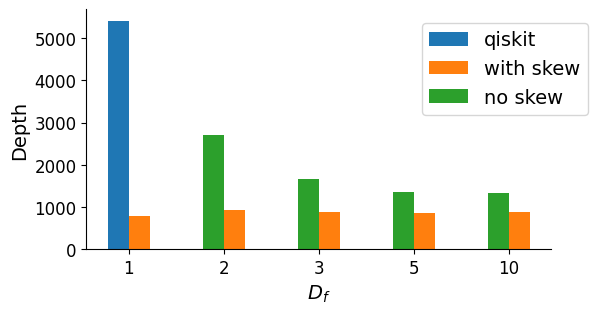

In [4]:
import matplotlib.pyplot as plt
import numpy as np

with open("data/no_skew_table.txt", 'r') as file:
    no_skew_list = eval(file.readline())
    braiding_list = eval(file.readline())

bar_width = 200

bar_spacing = 500
bar_positions_set1 = np.arange(5) * (bar_width * 2 + bar_spacing) + bar_spacing
bar_positions_set2 = bar_positions_set1 + bar_width
bar_positions_set3 = bar_positions_set2 + bar_width
bar_positions_set4 = bar_positions_set3 + bar_width
bar_positions_set5 = bar_positions_set4 + bar_width
fig, ax = plt.subplots(figsize = (6, 6))

list1 = []

for i in range(5):
    list1.append((no_skew_list['QAOA'][i] + no_skew_list['RCA'][i] + no_skew_list['VQE'][i]) / 3)

list2 = []

for i in range(5):
    list2.append((braiding_list['QAOA'][i] + braiding_list['RCA'][i] + braiding_list['VQE'][i]) / 3)

list3 = [5411, 0, 0, 0, 0]
plt.bar(bar_positions_set1, np.array(list3), width=bar_width, label=r'qiskit')

plt.bar(bar_positions_set2, np.array(list2), width=bar_width, label=r'with skew')
plt.bar(bar_positions_set1, np.array(list1) , width=bar_width, label=r'no skew')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
plt.xlabel(r'$D_f$', fontsize=14)
plt.ylabel('Depth', fontsize=14)
plt.legend(fontsize=14, bbox_to_anchor=(0.7, 0.52))
# plt.yticks([3])
ax.set_aspect(0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks((bar_positions_set1 + bar_positions_set2) / 2, [1, 2, 3, 5, 10])

plt.savefig('figs/no_skew_fig.pdf',bbox_inches='tight')

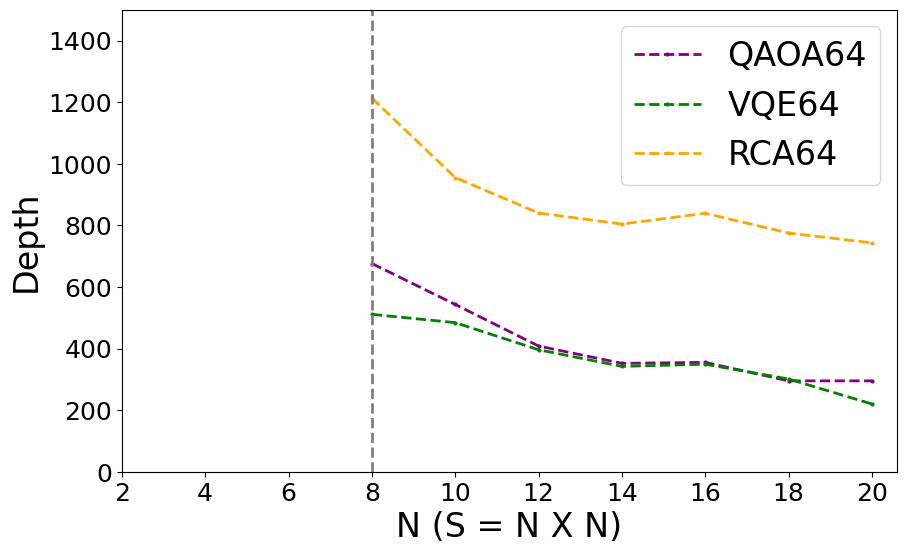

In [5]:
from math import *
import matplotlib.pyplot as plt
import numpy as np

with open('data/h_1.txt', 'r') as file:
    HSize_list = eval(file.readline())
    layer_index_list = eval(file.readline())

plt.figure(figsize=(10, 6))
plt.plot(HSize_list, layer_index_list['QAOA64'], label="QAOA64", color='purple', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(HSize_list, layer_index_list['VQE64'], label="VQE64", color='green', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(HSize_list, layer_index_list['RCA64'], label="RCA64", color='orange', marker='o', linestyle='dashed', linewidth=2, markersize=2)

plt.xticks(np.array(HSize_list), fontsize= 18)
plt.legend(fontsize = 24)

plt.yticks(fontsize=18)
plt.ylim(0, 1500)
plt.axvline(x=8, color='gray', linestyle='--', linewidth=2)
plt.xlabel('N (S = N X N)', fontsize=24)
plt.ylabel('Depth', fontsize=24) 
plt.savefig("figs/hardware_sense1.pdf")

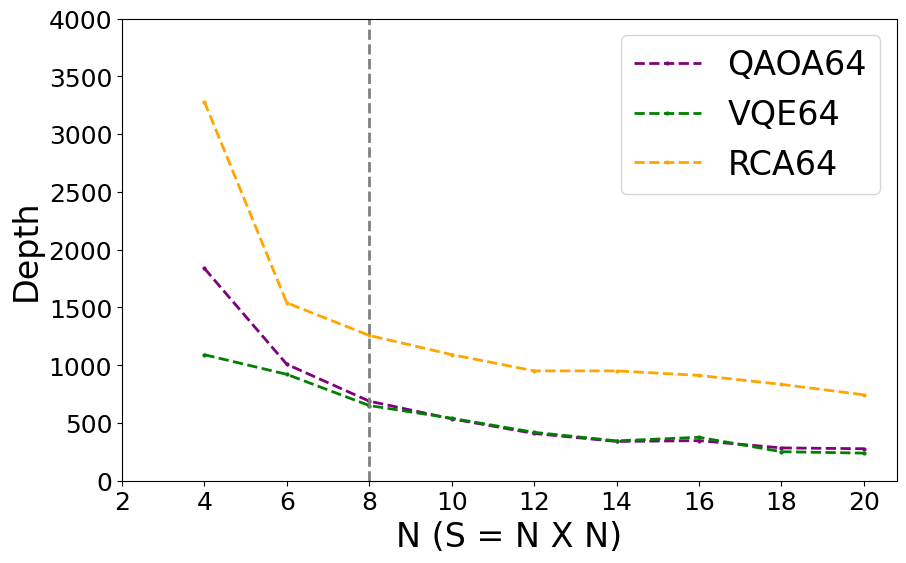

In [6]:
with open('data/h_5.txt', 'r') as file:
    HSize_list = eval(file.readline())
    layer_index_list = eval(file.readline())

plt.figure(figsize=(10, 6))
plt.plot(HSize_list, layer_index_list['QAOA64'], label="QAOA64", color='purple', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(HSize_list, layer_index_list['VQE64'], label="VQE64", color='green', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(HSize_list, layer_index_list['RCA64'], label="RCA64", color='orange', marker='o', linestyle='dashed', linewidth=2, markersize=2)

plt.xticks(np.array(HSize_list), fontsize= 18)
plt.legend(fontsize = 24)

plt.yticks(fontsize=18)
plt.ylim(0, 4000)
plt.axvline(x=8, color='gray', linestyle='--', linewidth=2)
plt.xlabel('N (S = N X N)', fontsize=24)
plt.ylabel('Depth', fontsize=24) 
plt.savefig("figs/hardware_sense5.pdf")

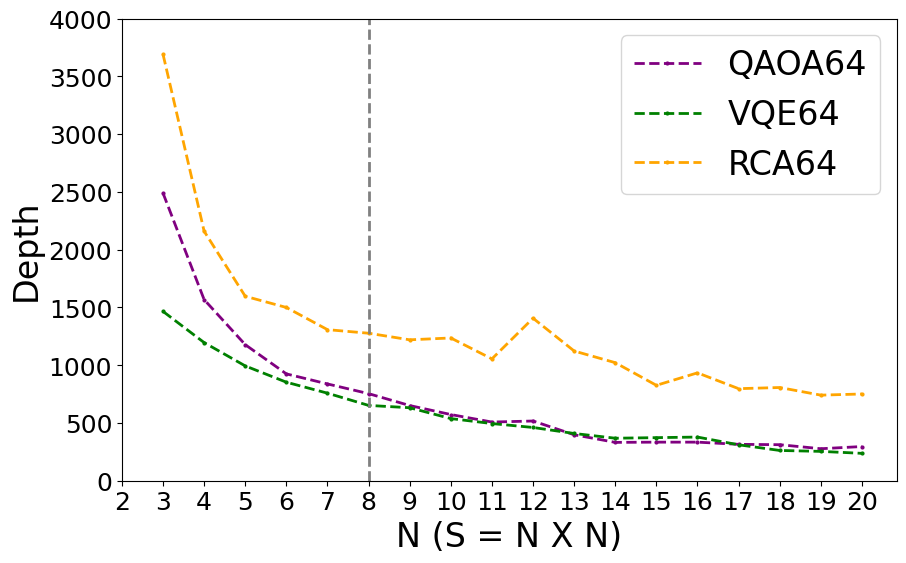

In [7]:
with open('data/h_10.txt', 'r') as file:
    HSize_list = eval(file.readline())
    layer_index_list = eval(file.readline())

plt.figure(figsize=(10, 6))
plt.plot(HSize_list, layer_index_list['QAOA64'], label="QAOA64", color='purple', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(HSize_list, layer_index_list['VQE64'], label="VQE64", color='green', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(HSize_list, layer_index_list['RCA64'], label="RCA64", color='orange', marker='o', linestyle='dashed', linewidth=2, markersize=2)

plt.xticks(np.array(HSize_list), fontsize= 18)
plt.legend(fontsize = 24)

plt.yticks(fontsize=18)
plt.ylim(0, 4000)
plt.axvline(x=8, color='gray', linestyle='--', linewidth=2)
plt.xlabel('N (S = N X N)', fontsize=24)
plt.ylabel('Depth', fontsize=24) 
plt.savefig("figs/hardware_sense10.pdf")

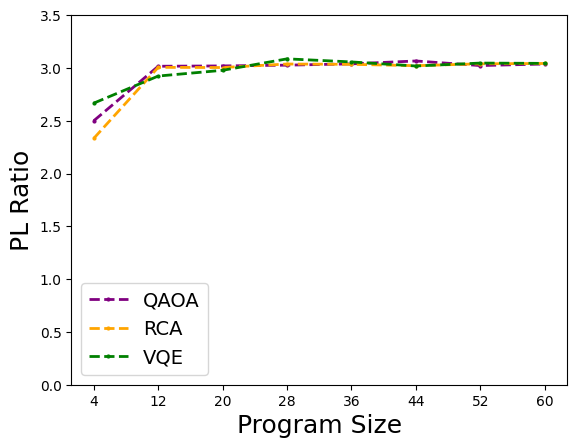

3.065843621399177 3.04208512673362 3.0859375


In [8]:
import matplotlib.pyplot as plt
import numpy as np

RefreshBound = 32
Row = 6
P = 0.75
AverageL = 24
a_list = ['QAOA', 'RCA', 'VQE']
time_index_map = {}
layer_index_map = {}

with open('data/pl_ratio.txt', 'r') as file:
    time_index_map = eval(file.readline())
    layer_index_map = eval(file.readline())

nqubit_list = []
for NQubit in range(4, 65, 8):
    nqubit_list.append(NQubit)

pl_ratio_map = {}
for a in time_index_map.keys():
    pl_ratio_map[a] = []
    for i in range(len(time_index_map[a])):
        pl_ratio_map[a].append(time_index_map[a][i] / layer_index_map[a][i])

plt.figure(0)
plt.plot(nqubit_list, pl_ratio_map['QAOA'], label="QAOA", color='purple', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(nqubit_list, pl_ratio_map['RCA'], label="RCA", color='orange', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(nqubit_list, pl_ratio_map['VQE'], label="VQE", color='green', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.xticks(np.array(nqubit_list))
plt.legend(fontsize = 14)
plt.ylim(0, 3.5)
plt.xlabel('Program Size', fontsize=18)
plt.ylabel('PL Ratio', fontsize=18) 
plt.show()
print(max(pl_ratio_map['QAOA']), max(pl_ratio_map['RCA']), max(pl_ratio_map['VQE']))

{0: [0.0, 0.48, 1.0, 1.0], 1: [0.0, 0.46, 0.98, 1.0], 2: [0.0, 0.34, 0.98, 1.0], 3: [0.0, 0.42, 1.0, 1.0]}


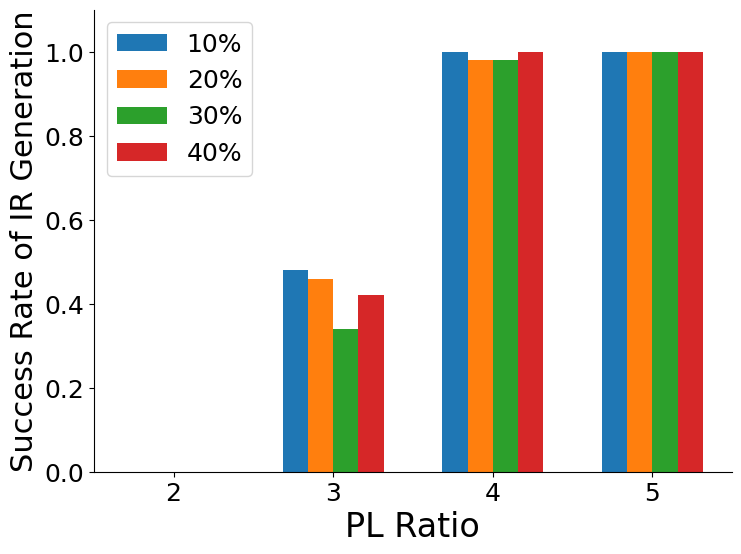

In [9]:
# diverse ir

with open("data/ir.txt", 'r') as file:
    overall_rsl = eval(file.readline())
    inter_space = eval(file.readline())
    inter_list = eval(file.readline())

max_inter_space = {}
for j in range(4):
    max_inter_space[j] = []
    g_max = []
    for i in range(50):
        gij = inter_space['1'][j][i * 20: (i + 1) * 20]
        g_max.append(max(gij))
    
    max_inter_space[j].append(len([g for g in g_max if g <= inter_list[0]]) / len(g_max))
    max_inter_space[j].append(len([g for g in g_max if g <= inter_list[1]]) / len(g_max))
    max_inter_space[j].append(len([g for g in g_max if g <= inter_list[2]]) / len(g_max))
    max_inter_space[j].append(len([g for g in g_max if g <= inter_list[3]]) / len(g_max))


print(max_inter_space)

bar_width = 0.06
bar_spacing = 0.14

bar_positions_set1 =  np.arange(4) * (bar_width * 4 + bar_spacing) + bar_spacing
bar_positions_set2 = bar_positions_set1 + bar_width
bar_positions_set3 = bar_positions_set2 + bar_width
bar_positions_set4 = bar_positions_set3 + bar_width
bar_positions_set5 = bar_positions_set4 + bar_width

fig, ax = plt.subplots(figsize=(10, 6))

plt.bar(bar_positions_set1, max_inter_space[0] , width=bar_width, label='10%')
plt.bar(bar_positions_set2, max_inter_space[1], width=bar_width, label='20%')
plt.bar(bar_positions_set3, max_inter_space[2], width=bar_width, label='30%')
plt.bar(bar_positions_set4, max_inter_space[3], width=bar_width, label='40%')

plt.xticks(fontsize=18)
plt.yticks(fontsize=18) 
plt.ylabel('Success Rate of IR Generation', fontsize=22)
plt.xlabel('PL Ratio', fontsize=24)
plt.legend(fontsize=18)
plt.ylim(0, 1.1)
ax.set_aspect(1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks((bar_positions_set1 + bar_positions_set2 + bar_positions_set3 + bar_positions_set4) / 4, [2, 3, 4, 5])
plt.show()  

{'0': [3.0392156862745097, 3.0392156862745097, 3.0392156862745097, 3.0392156862745097], '1': [3.0588235294117645, 3.0588235294117645, 3.0588235294117645, 3.0588235294117645], 'sqrt': [3.0392156862745097, 3.0588235294117645, 3.0588235294117645, 3.1176470588235294], '2': [3.0980392156862746, 3.1176470588235294, 3.1372549019607843, 3.176470588235294]}


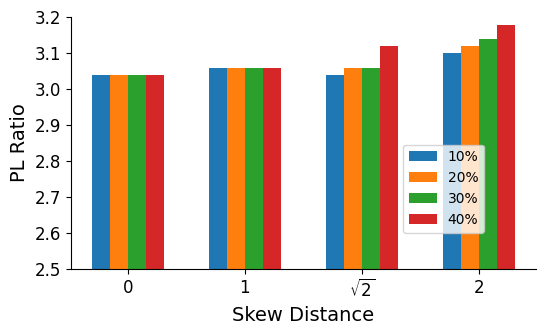

In [10]:
import matplotlib.pyplot as plt
import numpy as np

benchmarks= ["0.1", "0.2", "0.3", "0.4"] 
algorithm_type= ['0','1',r'$\sqrt{2}$','2']

with open('data/ir.txt', 'r') as file:
    overall_rsl = eval(file.readline())
    inter_space = eval(file.readline())
    inter_list = eval(file.readline())



layer_index_list = {}
for k in inter_space:
    layer_index_list[k] = []
    for j in range(4):
        g_max = 0
        for i in range(20):
            gij = inter_space[k][j][i * 50: (i + 1) * 50]
            g_max = max(g_max, sum(gij) / 51)
        layer_index_list[k].append(g_max)

print(layer_index_list)
bar_width = 0.02

bar_spacing = 0.05
bar_positions_set1 = np.arange(4) * (bar_width * 4 + bar_spacing) + bar_spacing
bar_positions_set2 = bar_positions_set1 + bar_width
bar_positions_set3 = bar_positions_set2 + bar_width
bar_positions_set4 = bar_positions_set3 + bar_width
bar_positions_set5 = bar_positions_set4 + bar_width
fig, ax = plt.subplots(figsize = (6, 6))

list1 = [layer_index_list[k][0] for k in layer_index_list]
list2 = [layer_index_list[k][1] for k in layer_index_list]
list3 = [layer_index_list[k][2] for k in layer_index_list]
list4 = [layer_index_list[k][3] for k in layer_index_list]

plt.bar(bar_positions_set1, np.array(list1) , width=bar_width, label=r'10%')
plt.bar(bar_positions_set2, np.array(list2), width=bar_width, label=r'20%')
plt.bar(bar_positions_set3, np.array(list3), width=bar_width, label=r'30%')
plt.bar(bar_positions_set4, np.array(list4), width=bar_width, label=r'40%')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
plt.xlabel('Skew Distance', fontsize=14)
plt.ylabel('PL Ratio', fontsize=14)
plt.ylim(2.5, 3.2)
plt.legend(fontsize=10, bbox_to_anchor=(0.7, 0.52))
# plt.yticks([3])
ax.set_aspect(0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks((bar_positions_set1 + bar_positions_set2 + bar_positions_set3 + bar_positions_set4) / 4, algorithm_type)

plt.savefig('figs/pl_ratio_diverse.pdf',bbox_inches='tight')

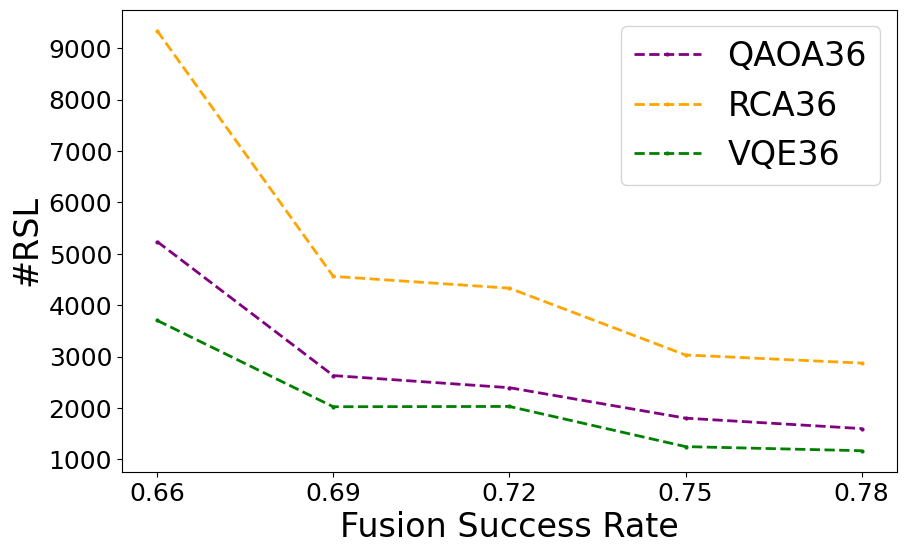

In [11]:
import numpy as np
import matplotlib.pyplot as plt


Refresh = False
NQubit = 36

algorithm_type = ['QAOA', 'QFT', 'VQE', 'RCA']

fusion_succ_list = [0.66, 0.69, 0.72, 0.75, 0.78]
stripe_length = [40, 28, 25, 20, 18]
algorithm_type = ['QAOA', 'QFT', 'VQE', 'RCA']

rsl_depth_map = {}

with open("data/fusion_succ_sensitivity.txt", "r") as file:
    fusion_succ_list = eval(file.readline())
    rsl_depth_map = eval(file.readline())


plt.figure(figsize=(10, 6))
plt.plot(fusion_succ_list, np.array(rsl_depth_map['QAOA']), label="QAOA36", color='purple', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(fusion_succ_list, np.array(rsl_depth_map['RCA']), label="RCA36", color='orange', marker='o', linestyle='dashed', linewidth=2, markersize=2)
plt.plot(fusion_succ_list, np.array(rsl_depth_map['VQE']), label="VQE36", color='green', marker='o', linestyle='dashed', linewidth=2, markersize=2)

plt.xticks(np.array(fusion_succ_list), fontsize=18)
plt.legend(fontsize = 24)

plt.yticks(fontsize=18)

plt.xlabel('Fusion Success Rate', fontsize=24)
plt.ylabel('#RSL', fontsize=24)
plt.savefig('figs/fusion_succ_sensitivity.pdf')

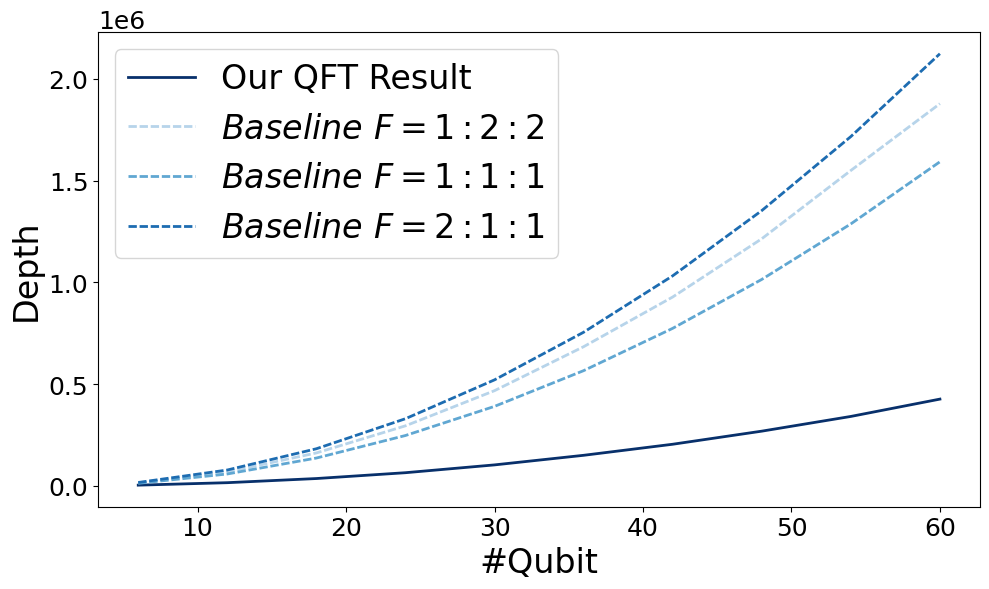

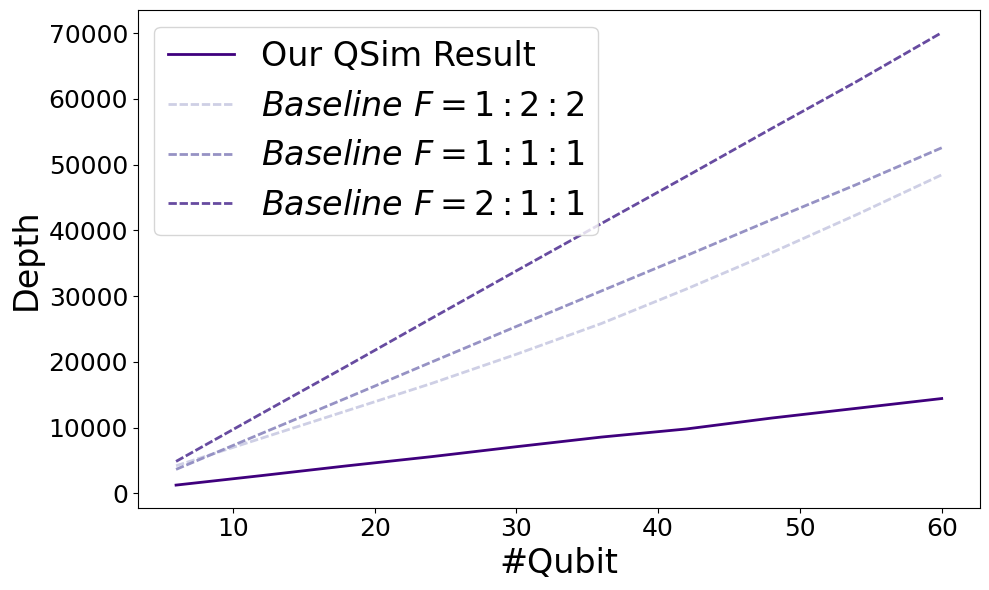

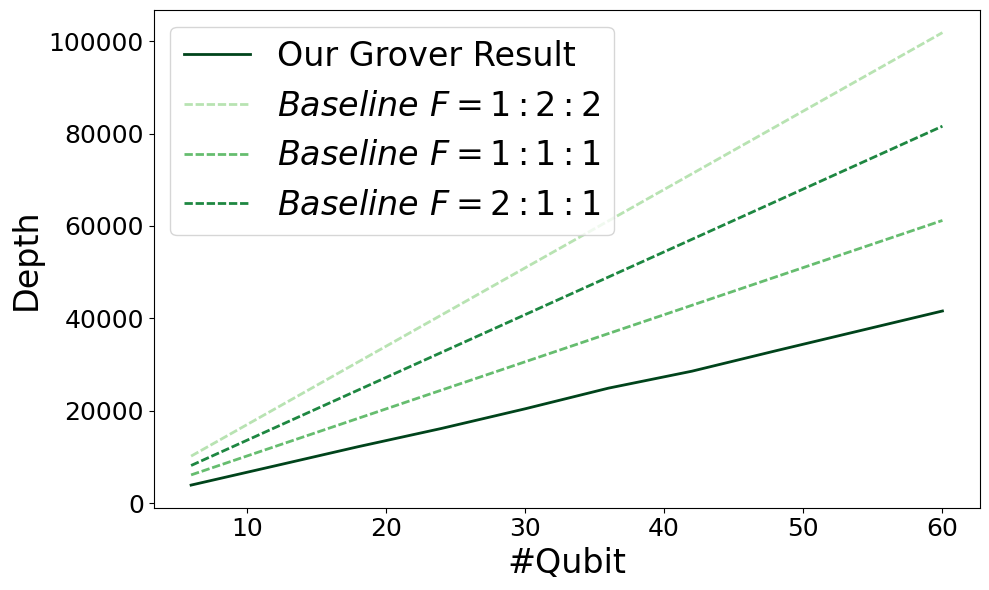

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


with open("data/qec_data.txt", 'r') as file:
    origin_depth = eval(file.readline())    

with open("data/qec_depth_us.txt", 'r') as file:
    our_depth = eval(file.readline())

plt.rcParams.update({
    'legend.fontsize': 24,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'lines.linewidth': 2.0,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'grid.alpha': 0.7,
    'grid.linestyle': '--'
})

Alg_list = ['QFT', 'QSim', 'Grover']
tag_list = ['a', 'b', 'c']
colors = [cm.Blues(np.linspace(0.3, 1, 4)), cm.Purples(np.linspace(0.3, 1, 4)), cm.Greens(np.linspace(0.3, 1, 4))]
N_list = range(6, 61, 6)
improv_index = []

for i, alg in enumerate(Alg_list):
    
    plt.figure(figsize=(10, 6))

    plt.plot(N_list, our_depth[alg], color=colors[i][3], label="Our " + alg + " Result", alpha=1.0, linewidth=2)
    plt.plot(N_list, origin_depth[alg][20: 30], color=colors[i][0], label=r"$Baseline \ F = 1:2:2$", alpha=1.0, linewidth=2, linestyle=(0, (3, 1)))
    plt.plot(N_list, origin_depth[alg][10: 20], color=colors[i][1], label=r"$Baseline \ F = 1:1:1$", alpha=1.0, linewidth=2, linestyle=(0, (3, 1)))
    plt.plot(N_list, origin_depth[alg][0: 10], color=colors[i][2], label=r"$Baseline \ F = 2:1:1$", alpha=1.0, linewidth=2, linestyle=(0, (3, 1)))

    plt.xlabel(r"#Qubit")
    plt.ylabel("Depth")
    plt.legend()
    plt.tight_layout()

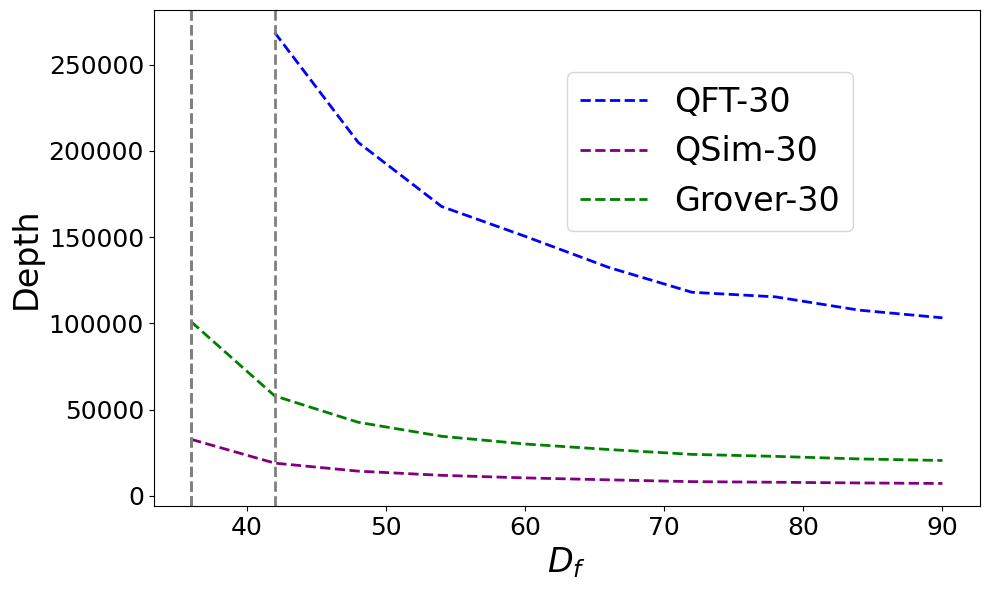

In [13]:
import matplotlib.pyplot as plt

with open("data/qec_refresh.txt", 'r') as file:
    our_depth = eval(file.readline())

N = 30
RL_list = [x for x in range(N, N * 3 + 1, 6)]
Alg_list = ['QFT', 'QSim', 'Grover']
colors = ['blue', 'purple', 'green']
start_point = [2, 1, 1]

plt.figure(figsize=(10, 6))
for i, alg in enumerate(Alg_list):
    plt.plot(RL_list[start_point[i]: ], our_depth[alg][start_point[i]: ], color=colors[i], label=alg + '-30', linestyle='--', alpha=1.0, linewidth=2)

plt.xlabel(r"$D_f$")
plt.ylabel("Depth")
plt.legend(bbox_to_anchor=(0.48, 0.52))
plt.tight_layout()
plt.axvline(x=42, color='gray', linestyle='--', linewidth=2)
plt.axvline(x=36, color='gray', linestyle='--', linewidth=2)
plt.axvline(x=36, color='gray', linestyle='--', linewidth=2)